# Practice 2: Symbolic Regression via Genetic Programming
### Biologically-Inspired Methods

**Author:** Ivan Ocheretianyi (NIA: 100487317)  
**Date:** April 12, 2026

**Abstract:**

This notebook details the implementation of a Genetic Programming (GP) system for *Symbolic Regression*. The objective is to evolve a mathematical expression tree that approximates an unknown target function by minimizing the Mean Absolute Error over a given dataset. Serving as both the executable script and the formal report, this notebook justifies all architectural and parameter choices alongside the code, and provides an experimental comparison of four evolutionary configurations — Tournament and Roulette selection, each with and without fitness sharing — evaluated over 10 independent runs.

Submission contains this notebook file, as well as .jl file with code to simulate 10 iterations analysis.

In [49]:
# Import all necessary packages
# import Pkg; Pkg.add("Latexify"); Pkg.add("StatsBase");  # for the first time run
using Latexify
using Random
using StatsBase: sample
using CSV
using DataFrames
using Plots
using Statistics

## 1. Data Pipeline & Preprocessing

Before the GP can evaluate any individuals, the raw data must be loaded and transformed into a clean numerical format. This section handles data ingestion and the automatic separation of features ($X$) and targets ($y$).

**Loading (`load_and_clean_csv`):** Data is loaded using Julia's `CSV.jl` library, which automatically handles headers and missing values, converting the result directly into a `Float64` matrix. This is significantly simpler and faster than manual row-by-row validation.

**Generalization (`prepare_data`):** The feature/target split is fully dynamic — features $X$ are sliced with `1:end-1` and the target $y$ with `end`, so the algorithm never hardcodes the number of columns and adapts automatically to any dataset shape.

In [89]:
function load_and_clean_csv(file_path::String)
    df = CSV.read(file_path, DataFrame)
    return Matrix{Float64}(df)
end

function prepare_data(file_path::String)
    data = load_and_clean_csv(file_path)
    println("Loaded clean CSV data: ", size(data))

    X = data[:, 1:end-1]
    y = data[:, end]

    return X, y
end

prepare_data (generic function with 1 method)

## 2. Data Structures

This section defines the core types that represent individuals in the population. Unlike binary-mask GAs where an individual is a flat vector, Genetic Programming represents each individual as a **tree** — a mathematical expression built from operations and variables.

**`Variable` and `Operation`:** The atomic building blocks of any expression tree. A `Variable` holds a named input (e.g. $x$, $y$) and its current numeric value, while an `Operation` holds a function symbol (e.g. `+`, `sin`, `log`).

**`TreeNode`:** A recursive structure that forms the tree. Each node holds either a `Variable`, a constant `Float64`, or an `Operation`, along with a vector of child nodes. Terminal nodes (leaves) hold variables or constants; internal nodes hold operations.

**`Tree`:** The individual itself — wrapping the root `TreeNode` with its variable bindings, current fitness score, and cached predictions. Overloading `Base.isless` on fitness allows Julia's built-in `minimum` and `sort` to work directly on populations.

**`Population`:** A simple container grouping all individuals with the population size, keeping the evolutionary loop clean and self-contained.

In [51]:
mutable struct Variable
    name::String
    value::Float64
end

Base.show(io::IO, var::Variable) = print(io, var.name)

mutable struct Operation
    name::String
end

Base.show(io::IO, op::Operation) = print(io, op.name)

mutable struct TreeNode
    value::Union{Float64, Operation, Variable}
    children::Vector{TreeNode}
end

mutable struct Tree
    head::TreeNode
    variables::Vector{Variable}
    fitness::Float64
    predictions::Vector{Float64}
end

Base.isless(a::Tree, b::Tree) = a.fitness < b.fitness

mutable struct Population
    individuals::Vector{Tree}
    size::Int
end

## 3. Tree Utilities — Printing & Evaluation

This section implements two independent but equally important capabilities: rendering a tree as a human-readable mathematical expression, and numerically evaluating it given a set of variable values.

**Tree Serialization (`stringNode`, `stringTree`):** The tree is traversed recursively, assembling a fully-parenthesized infix string. Unary operations (e.g. `sin`, `log`) produce `(op x)` while binary operations produce `(x op y)`. Full parenthesization ensures there is no ambiguity in operator precedence.

**LaTeX Rendering (`printBeautifulTree`):** The infix string is parsed into an expression and then rendered as a formatted mathematical formula. This makes inspecting the best-found solution significantly more readable than printing raw strings.

**Safe Operation Execution (`performOperation`):** Applies an operation to its operands with domain safety checks — `sqrt` and `log` guard against negative and non-positive inputs respectively, and division guards against a zero denominator. Any violation throws an exception, which is caught upstream in `computeFitness!` and penalized with $\infty$.

**Recursive Evaluation (`computeNode`, `computeTree`):** The tree is evaluated bottom-up — terminal nodes return their variable's current value or the constant directly, while internal operation nodes recursively evaluate their children first and then apply `performOperation` to the results.

In [52]:
function stringNode(node::TreeNode)
    if typeof(node.value) == Variable
        return "(" * node.value.name * ")"
    end
    if typeof(node.value) != Operation
        return "(" * string(node.value) * ")"
    end

    op1 = stringNode(node.children[1])
    if length(node.children) == 1
        return "(" * node.value.name * op1 * ")"
    end

    op2 = stringNode(node.children[2])
    return "(" * op1 * node.value.name * op2 * ")"
end

function stringTree(tree::Tree)
    stringNode(tree.head)
end

function printBeautifulTree(tree::Tree)
    string_tree = stringTree(tree)
    # Convert the string into a mathematical expression
    expressionTree = Meta.parse(string_tree)
    # Render it
    display(latexify(expressionTree))
end

function performOperation(operation::Operation, operand1::Float64, operand2=nothing)
    if operation.name == "sqrt"
        operand1 < 0 ? throw(DomainError(operand1)) : sqrt(operand1)
    elseif operation.name == "log"
        operand1 <= 0 ? throw(DomainError(operand1)) : log(operand1)
    elseif operation.name == "sin"
        sin(operand1)
    elseif operation.name == "cos"
        cos(operand1)
    elseif operation.name == "abs"
        abs(operand1)
    elseif operation.name == "floor"
        floor(operand1)
    elseif operation.name == "ceil"
        ceil(operand1)
    elseif operand2 !== nothing
        if operation.name == "+"
            operand1 + operand2
        elseif operation.name == "-"
            operand1 - operand2
        elseif operation.name == "*"
            operand1 * operand2
        elseif operation.name == "/"
            operand2 == 0 ? throw(DivideError()) : operand1 / operand2
        end
    else
        # catch error and make fitness be infinity
        throw("$(operation.name) is a binary operation and requires two operands")
    end
end

function computeNode(node::TreeNode)
    if typeof(node.value) == Variable
        return node.value.value
    end
    if typeof(node.value) != Operation
        return node.value
    end

    op1 = computeNode(node.children[1])
    if length(node.children) == 1
        return performOperation(node.value, op1)
    end

    op2 = computeNode(node.children[2])
    return performOperation(node.value, op1, op2)
end

function computeTree(tree::Tree)
    computeNode(tree.head)
end

computeTree (generic function with 1 method)

## 4. Tree & Population Generation

This section implements the random generation of trees and populations — the starting point of the evolutionary search.

**Operation Set (`generateOperation`):** Each of the 11 available operations is sampled with equal probability $\frac{1}{11}$. The set includes 7 unary operations (`sqrt`, `log`, `sin`, `cos`, `abs`, `floor`, `ceil`) and 4 binary ones (`+`, `-`, `*`, `/`), giving the GP a rich vocabulary of mathematical primitives to construct expressions from.

**Terminal Generation (`generateNumber`):** Leaf nodes are filled with equal probability among three options — a random float in $[0, 10]$, a random integer in $[0, 10]$, or one of the input variables. The 50% probability of picking a variable ensures the evolved expressions are genuinely data-dependent rather than converging to constants.

**Variable Naming (`generateVariables`):** Variables are assigned single-character names drawn from a fixed alphabet (the most commonly used letters are first), starting with $x, y, z, \ldots$, making the LaTeX output clean and readable for any number of input features.

**Recursive Node Construction (`generateNode`):** Trees are built top-down with two configurable strategies — *full* trees always expand to the maximum depth, while *grow* trees can terminate early at any level. A minimum depth of 2 is enforced to prevent trivially shallow individuals in early generations. Unary operations always produce one child, binary operations always produce two.

**Population Initialization (`Population`):** Each individual is generated with a randomly sampled depth between 3 and 7, with the full/grow method chosen randomly per tree. This *ramped half-and-half* style initialization ensures the starting population contains a diverse mix of small and large expressions, giving the search a broad initial foothold.

In [53]:
function generateOperation()
    randNum = rand()
    if randNum < 1/11
        Operation("sqrt")
    elseif randNum < 2/11
        Operation("log")
    elseif randNum < 3/11
        Operation("sin")
    elseif randNum < 4/11
        Operation("cos")
    elseif randNum < 5/11
        Operation("abs")
    elseif randNum < 6/11
        Operation("floor")
    elseif randNum < 7/11
        Operation("ceil")
    elseif randNum < 8/11
        Operation("+")
    elseif randNum < 9/11
        Operation("-")
    elseif randNum < 10/11
        Operation("*")
    else
        Operation("/")
    end
end

function generateNumber(variables::Vector{Variable})
    randNum = rand()
    if randNum < 1/4  # generate float from 0 to 10
        10*rand()
    elseif randNum < 1/2  # generate int from 0 to 10
        float(rand(0:10))
    else
        rand(variables)  # take randomly variable
    end
end

function generateVariables(num::Int)
    alphabet = "xyznkmuvwabcdefghijpqrtslo"
    alphabetVector = Vector{String}()
    for el in alphabet
        push!(alphabetVector, string(el))
    end
    variableNames = alphabetVector[1:num]

    variables = Vector{Variable}()

    for name in variableNames
        push!(variables, Variable(name, 0))  # make 0 value as default
    end
    return variables
end

function generateNode(variables::Vector{Variable}, minDepth::Int,
                                                  depth::Int, full::Bool)
    if depth == 0
        TreeNode(generateNumber(variables), Vector{TreeNode}())
    else
      if rand() < 0.5 || full || minDepth > 0
          operation = generateOperation()
          node = TreeNode(operation, Vector{TreeNode}())
          child1 = generateNode(variables, minDepth-1, depth-1, full)
          node.children = [child1]
          if operation.name in ["+", "-", "*", "/"]
              push!(node.children, generateNode(variables, minDepth-1,
                                                        depth-1, full))
          end
          return node
      else
          TreeNode(generateNumber(variables), Vector{TreeNode}())
      end
    end
end

function Tree(depth::Int, numVariables::Int, full::Bool)
    variables = generateVariables(numVariables)
    minDepth = 2
    head = generateNode(variables, minDepth, depth, full)
    return Tree(head, variables, 0.0, Float64[])
end

function Population(size::Int, numVariables::Int)
    population = Population(Vector{Tree}(), size)
    for i in 1:size
        push!(population.individuals, Tree(rand(3:7), numVariables, rand(Bool)))
    end
    return population
end

Population

## 5. Fitness Evaluation

This section defines how the quality of each individual tree is measured — the core selection pressure driving the entire evolutionary process.

**Variable Binding (`assignValues!`):** Before a tree can be evaluated on a data row, its variable nodes must be loaded with the corresponding feature values. This function maps each column of a data row onto the matching `Variable` object in the tree, updating it in-place. Although the functions under study are single-variable in both datasets, the implementation was designed to accept an arbitrary number of input variables, ensuring generalization to higher-dimensional problems.

**Fitness Computation (`computeFitness!`):** The tree is evaluated row-by-row across the entire dataset. For each row, variable values are assigned, the tree is computed recursively, and the absolute error $|prediction - y_i|$ is accumulated and averaged, yielding the **Mean Absolute Error (MAE)** as the fitness score. Predictions are cached in `tree.predictions` for later use by the niching mechanism. Any domain error during evaluation — such as `log` of a negative number or division by zero — is caught and penalized with $\infty$, ensuring the individual is eliminated by selection.

**Bulk Evaluation (`computePopulationFitness!`):** Iterates over the entire population and evaluates each tree in-place, keeping all fitness values synchronized before selection begins.

**Elite Extraction (`best`):** Since `Base.isless` is overloaded to compare trees by fitness, Julia's built-in `minimum` directly returns the fittest individual in the population without any custom logic.

In [54]:
function assignValues!(variables::Vector{Variable}, values::Vector{Float64})
    if length(variables) != length(values)
        throw("amount of values should be same as of variables")
    end
    for i in 1:length(variables)
        variables[i].value = values[i]
    end
end

function computeFitness!(tree::Tree, X::Matrix{Float64}, y::Vector{Float64})
    fitness = 0.0
    num_rows = size(X, 1)
    tree.predictions = zeros(Float64, num_rows)

    try
        for i in 1:num_rows
            assignValues!(tree.variables, X[i, :])
            prediction = computeTree(tree)

            tree.predictions[i] = prediction
            fitness += abs(prediction - y[i])
        end
    catch e
        fitness = Inf
    end
    tree.fitness = fitness / num_rows
end

function computePopulationFitness!(population::Population, X::Matrix{Float64},
                                                          y::Vector{Float64})
    for tree in population.individuals
        computeFitness!(tree, X, y)
    end
end

function best(population::Population)
    minimum(population.individuals)
end

best (generic function with 1 method)

## 6. Tree Navigation Utilities

Before evolutionary operators can be applied, the algorithm must be able to traverse and inspect the tree structure. This section provides the foundational navigation primitives used by both crossover and mutation.

**Node Collection (`getAllNodeDescendants!`, `getAllTreeNodes`):** Performs a recursive post-order traversal of the tree, collecting all nodes into a flat vector. Having a flat list of all nodes is essential for the genetic operators, which need to select random nodes as crossover or mutation points.

**Parent Lookup (`getParent`):** Given a target node, searches the flat node list for the node that contains it as a direct child, returning both the parent and the child's index within it. This is required by crossover, which must rewire parent-child relationships when swapping subtrees between two individuals.

**Node Depth (`getNodeDepth`):** Recursively computes the depth of a target node relative to the tree root, returning $-1$ if the node is not found on the current path. This is overloaded to accept either a raw `TreeNode` head or a `Tree` object for convenience. Depth information is used during crossover to ensure that subtree swaps do not produce offspring that exceed the maximum permitted tree depth.

**Node Height (`getNodeHeight`):** Recursively computes the height of a subtree rooted at a given node — the length of the longest path from that node down to a leaf. Combined with depth, height allows the crossover operator to verify that a swap remains within the maximum depth: $depth(node) + height(subtree) \leq depth_{max}$.

In [55]:
function getAllNodeDescendants!(node::TreeNode, allNodes::Vector{TreeNode})
    if typeof(node.value) == Operation
        getAllNodeDescendants!(node.children[1], allNodes)
        if length(node.children) == 2
            getAllNodeDescendants!(node.children[2], allNodes)
        end
    end
    push!(allNodes, node)
end

function getAllTreeNodes(tree::Tree)
    allNodes = Vector{TreeNode}()
    getAllNodeDescendants!(tree.head, allNodes)
    return allNodes
end

function getParent(treeNodes::Vector{TreeNode}, child::TreeNode)
    for node in treeNodes
        if child in node.children
            return (node, findfirst(==(child), node.children))
        end
    end
    return (nothing, nothing)
end

function getNodeDepth(target_node::TreeNode, current_head::TreeNode)
    if target_node === current_head
        return 0
    end

    if isempty(current_head.children)
        return -1 # Represents 'not found' in this path
    end

    for child in current_head.children
        child_depth = getNodeDepth(target_node, child)
        if child_depth != -1
            return 1 + child_depth
        end
    end

    return -1
end

function getNodeDepth(node::TreeNode, tree::Tree)
    getNodeDepth(node, tree.head)
end

function getNodeHeight(node::TreeNode)
    if isempty(node.children)
        0
    elseif length(node.children) == 1
        1 + getNodeHeight(node.children[1])
    else
        1 + max(getNodeHeight(node.children[1]), getNodeHeight(node.children[2]))
    end
end

getNodeHeight (generic function with 1 method)

## 7. Evolutionary Operators — Mutation & Crossover

This section implements the two genetic operators that drive exploration of the expression space across generations.

**Mutation (`mutation!`):** Three mutation strategies are available, each selected with equal probability $\frac{1}{3}$:

- **Operation replacement:** A random internal node is selected and its operation is replaced with a newly generated one. Critically, arity changes are handled explicitly — if the new operation requires fewer children than the old one, a random surviving child is kept; if it requires more, a new child subtree is generated within the remaining depth budget. This ensures the tree remains structurally valid after every operation swap.
- **Terminal replacement:** A random leaf node (variable or constant) is selected and replaced with a newly generated terminal, leaving the tree structure intact.
- **Subtree replacement:** A random node anywhere in the tree is selected and entirely replaced with a freshly generated subtree, constrained by the remaining depth budget $depth_{potential} = depth_{max} - depth(node)$.

If a preferred mutation type is unavailable (e.g. no operation nodes exist), the strategy gracefully falls through to the next option.

**Crossover (`crossover!`):** Implements standard subtree crossover — a random node is selected from each parent and the two corresponding subtrees are swapped. Candidate points are resampled until both offspring satisfy the depth constraint:

$$depth(node_1) + height(subtree_2) \leq depth_{max}$$
$$depth(node_2) + height(subtree_1) \leq depth_{max}$$

All four cases of node position are handled explicitly — both nodes being roots, only one being a root, or neither — ensuring parent-child relationships are always correctly rewired after the swap.

In [56]:
function mutation!(tree::Tree, maximumDepth::Int)
    randNum = rand()
    allNodes = getAllTreeNodes(tree)

    if tree.head === nothing || isempty(allNodes)
        return # Cannot mutate an empty tree
    end

    if randNum < 1/3
        operations = filter(x -> x.value isa Operation, allNodes)
        if !isempty(operations)
            node = rand(operations)
            old_arity = length(node.children)

            new_op = generateOperation()
            new_arity = new_op.name in ["+", "-", "*", "/"] ? 2 : 1

            if new_arity < old_arity
                keep_idx = rand(1:old_arity)
                node.children = [node.children[keep_idx]]

            elseif new_arity > old_arity
                # -1 because child is one level deeper
                depthPotential = max(0, maximumDepth - getNodeDepth(node, tree) - 1)
                minDepth = rand(0:max(0, min(1, depthPotential)))
                new_child = generateNode(tree.variables, minDepth,
                                rand(minDepth:min(4, depthPotential)), rand(Bool))

                if rand() < 0.5
                    pushfirst!(node.children, new_child)
                else
                    push!(node.children, new_child)
                end
            end

            node.value = new_op
        else
            # Fallback to the following mutation option
            randNum += 1/3
        end
    end
    if 1/3 <= randNum < 2/3
        terminals = filter(x -> x.value isa Variable || x.value isa Float64, allNodes)
        if !isempty(terminals)
            node = rand(terminals)
            node.value = generateNumber(tree.variables)
        else
            # Fallback to the following mutation option
            randNum += 1/3
        end
    end
    if randNum >= 2/3
        if isempty(allNodes)
            return
        end
        node = rand(allNodes)
        depthPotential = max(0, maximumDepth - getNodeDepth(node, tree))
        minDepth = rand(0:max(0, min(1, depthPotential)))
        new_branch = generateNode(tree.variables, minDepth,
                        rand(minDepth:min(4, depthPotential)), rand(Bool))
        node.value = new_branch.value
        node.children = new_branch.children
    end
end

function crossover!(tree1::Tree, tree2::Tree, maximumDepth::Int)
    allNodesTree1 = getAllTreeNodes(tree1)
    allNodesTree2 = getAllTreeNodes(tree2)

    properDepths = false
    crossoverNode1 = nothing
    crossoverNode2 = nothing

    while !properDepths
        crossoverNode1 = rand(allNodesTree1)
        crossoverNode2 = rand(allNodesTree2)

        height1 = getNodeHeight(crossoverNode1)
        height2 = getNodeHeight(crossoverNode2)

        # so we stay it permitted depth
        properDepths = (height1 + getNodeDepth(crossoverNode2, tree2) <= maximumDepth
                    &&  height2 + getNodeDepth(crossoverNode1, tree1) <= maximumDepth)
    end

    parent1, idx1 = getParent(allNodesTree1, crossoverNode1)
    parent2, idx2 = getParent(allNodesTree2, crossoverNode2)

    if isnothing(parent1) && crossoverNode1 != tree1.head ||
        isnothing(parent2) && crossoverNode2 != tree2.head
        throw("Error: Node without parent")
    end

    if crossoverNode1 == tree1.head && crossoverNode2 == tree2.head
        tree1.head = crossoverNode2
        tree2.head = crossoverNode1
    elseif crossoverNode1 == tree1.head
        tree1.head = crossoverNode2
        parent2.children[idx2] = crossoverNode1
    elseif crossoverNode2 == tree2.head
        tree2.head = crossoverNode1
        parent1.children[idx1] = crossoverNode2
    else
        parent1.children[idx1] = crossoverNode2
        parent2.children[idx2] = crossoverNode1
    end
end

crossover! (generic function with 1 method)

## 8. Selection Mechanisms

Two selection strategies are implemented and compared experimentally. Both serve the same purpose — choosing which individuals reproduce — but differ fundamentally in how selection pressure is applied.

**Tournament Selection (`tournament_selection`):** Three individuals are sampled at random without replacement, and the one with the lowest MAE is selected as the winner. Selection pressure is controlled purely by relative rank, making this method robust to the absolute scale of fitness values and resistant to domination by a single outstanding individual early in the run.

**Roulette Wheel Selection (`build_wheel`, `roulette_spin`):** Each individual is assigned a selection probability proportional to the inverse of its fitness — $p_i = \frac{1/(f_i + \epsilon)}{\sum_j 1/(f_j + \epsilon)}$ — so that lower MAE corresponds to a higher probability of being selected. The cumulative distribution is precomputed once per generation via `cumsum`, and each spin uses `searchsortedfirst` to locate the winning slot in $O(\log N)$ time. The $\epsilon$ constant (`1e-6`) prevents division by zero in the case of a perfect prediction (unfortunately, it was never reached). This method is sensitive to fitness scale — when all MAE values are of similar magnitude, selection probabilities collapse toward $\frac{1}{N}$, reducing selection to near-random sampling.

In [57]:
function tournament_selection(population::Population)
    ind1, ind2, ind3 = sample(population.individuals, 3, replace=false)
    min(ind1, ind2, ind3)
end

function build_wheel(population::Population)
    fitnesses = [ind.fitness for ind in population.individuals]
    inverted = 1.0 ./ (fitnesses .+ 1e-6)
    probs = inverted ./ sum(inverted)
    return cumsum(probs)
end

function roulette_spin(population::Population, wheel::Vector{Float64})
    idx = min(searchsortedfirst(wheel, rand()), length(population.individuals))
    return population.individuals[idx]
end

roulette_spin (generic function with 1 method)

## 9. Niching — Fitness Sharing

A known weakness of standard GAs and GP is premature convergence — the population collapses into a single region of the search space, losing the diversity needed to escape local optima. This section implements **fitness sharing**, a niching mechanism that discourages redundant individuals by penalizing those whose predictions are too similar to their neighbors.

**Phenotypic Distance (`phenotypic_distance`):** Two individuals are compared not by their genotype (tree structure) but by their *phenotype* — the vector of predictions they produce over the dataset. Distance is measured as the Euclidean norm between prediction vectors. This is a deliberate choice: two structurally different trees that produce identical outputs are functionally equivalent and should be treated as neighbors regardless of their structural difference.

**Fitness Sharing (`apply_fitness_sharing!`):** For each individual $i$, a niche count $m_i$ is computed by summing the sharing function $sh(d_{ij})$ over all neighbors $j$ within distance $\sigma_{s}$:

$$sh(d_{ij}) = 1 - \left(\frac{d_{ij}}{\sigma_{s}}\right)^\alpha, \quad d < \sigma_{s}$$

The individual's fitness is then multiplied by $m_i$, effectively penalizing individuals that occupy a crowded region of the phenotype space. Individuals with infinite fitness (invalid trees) are excluded from both the computation and the penalization.

**Adaptive Threshold (`compute_sigma_share`):** Rather than fixing $\sigma_{s}$ as a static hyperparameter, it is computed dynamically each generation as half the median pairwise phenotypic distance across the population. This allows the sharing radius to adapt naturally to the scale of the current population's diversity.

In [58]:
function phenotypic_distance(preds1::Vector{Float64}, preds2::Vector{Float64})
    return sqrt(sum((preds1 .- preds2).^2))
end

function apply_fitness_sharing!(population::Population,
                                sigma_share::Float64, alpha::Float64=1.0)
    N = length(population.individuals)
    m = zeros(Float64, N)

    for i in 1:N
        if population.individuals[i].fitness == Inf
            continue
        end

        for j in 1:N
            if population.individuals[j].fitness == Inf
                continue
            end

            d_ij = phenotypic_distance(
                population.individuals[i].predictions,
                population.individuals[j].predictions
            )

            if d_ij < sigma_share
                sh = 1.0 - (d_ij / sigma_share)^alpha
                m[i] += sh
            end
        end
    end

    for i in 1:N
        if population.individuals[i].fitness != Inf
            population.individuals[i].fitness *= m[i]
        end
    end
end

function compute_sigma_share(population::Population)
    all_preds = [ind.predictions for ind in population.individuals
                 if ind.fitness != Inf && !isempty(ind.predictions)]
    if isempty(all_preds)
        return 1.0
    end
    distances = [phenotypic_distance(all_preds[i], all_preds[j])
                 for i in 1:length(all_preds) for j in i+1:length(all_preds)]
    return isempty(distances) ? 1.0 : median(distances) * 0.5
end

compute_sigma_share (generic function with 1 method)

## 10. The Main Evolutionary Loop

This section implements the core generational cycle, tying together all previously defined components into a unified evolutionary engine.

**Elitism (`elite_count`):** At the start of each generation, the top `elite_count` individuals are extracted by raw fitness and preserved unconditionally into the next generation. This guarantees monotonic improvement — the best solution found can never be lost due to destructive crossover or mutation. Although slides were suggesting usage of non-eletism approach, its performance was worse.

**Fitness Sharing (optional):** If niching is enabled, fitness sharing is applied *after* elites are extracted but *before* selection. This ordering is deliberate — elites are chosen based on true MAE, while the penalized fitness values are only used to guide selection pressure toward diverse offspring.

**Operator Application:** The new population is filled via a probabilistic operator dispatch:
- With probability `crossover_rate` — two parents are selected and crossed over, producing two offspring.
- With probability `mutation_rate` — one parent is selected and mutated.
- Otherwise — one parent is copied directly (reproduction).

This treats crossover, mutation, and reproduction as competing strategies rather than sequential stages, which is more faithful to the standard GP formulation.

**Depth Enforcement:** The maximum tree depth is passed through to both `crossover!` and `mutation!`, ensuring no offspring ever exceeds the structural complexity budget regardless of the operator applied.

**`runSymbolicRegression`:** A convenience wrapper around `run_selection` that handles naming, timing, and result printing. It renders the best found tree as a LaTeX expression via `printBeautifulTree` and reports its height, providing a human-readable summary of the final solution.

In [90]:
function run_selection(population::Population, selection_method::Symbol, printable::Bool, niche::Bool,
    X::Matrix{Float64}, y::Vector{Float64}, generations::Int, maximumDepth::Int,
    mutation_rate::Float64, crossover_rate::Float64, elite_count::Int)

    best_fitness_hist = Float64[]

    # Initial fitness calculation
    computePopulationFitness!(population, X, y)

    for i in 0:generations
        sorted = sort(population.individuals, by = x -> x.fitness)
        elites = [deepcopy(ind) for ind in sorted[1:elite_count]]

        best_ind = deepcopy(elites[1])
        current_fitness = best_ind.fitness

        push!(best_fitness_hist, current_fitness)
        if printable
            println("Generation $i. Best Fitness: $current_fitness")
        end

        if niche
            # fitness sharing
            sigma_share = compute_sigma_share(population)
            apply_fitness_sharing!(population, sigma_share, 1.0)
        end


        if selection_method == :roulette
            wheel = build_wheel(population)
            select = () -> roulette_spin(population, wheel)
        elseif selection_method == :tournament
            select = () -> tournament_selection(population)
        else
            throw(ArgumentError("Unknown selection method: $selection_method"))
        end

        new_individuals = Vector{Tree}()

        while length(new_individuals) < population.size - elite_count
            randNum = rand()
            if randNum < crossover_rate
                # Crossover
                parent1 = select()
                parent2 = select()

                child1 = deepcopy(parent1)
                child2 = deepcopy(parent2)
                crossover!(child1, child2, maximumDepth)

                push!(new_individuals, child1)
                # Only push another if we have not exceeded population size
                if length(new_individuals) < population.size - elite_count
                    push!(new_individuals, child2)
                end
            elseif randNum < crossover_rate + mutation_rate
                # Mutation
                parent = select()
                child = deepcopy(parent)
                mutation!(child, maximumDepth)
                push!(new_individuals, child)
            else
                # Reproduction
                parent = select()
                child = deepcopy(parent)
                push!(new_individuals, child)
            end
        end

        # Elites go in unconditionally
        population.individuals = [elites; new_individuals]
        computePopulationFitness!(population, X, y)
    end
    return (best_fitness_hist, best(population))
end

function runSymbolicRegression(population::Population, X::Matrix{Float64}, y::Vector{Float64}, selection_method::Symbol, printable::Bool, niche::Bool, generations::Int,
    maximum_depth::Int, mutation_rate::Float64=0.25, crossover_rate::Float64=0.5, elite_count::Int = 3)

    name = niche ? "Niche " : ""
    if selection_method == :roulette
        name *= "Roulette"
    elseif selection_method == :tournament
        name *= "Tournament"
    else
        throw(ArgumentError("Unknown selection method: $selection_method"))
    end
    if printable
        println(name)
    end
    start_time = time_ns()
    history, best_tree = run_selection(population, selection_method, printable, niche,
                X, y, generations, maximum_depth, mutation_rate, crossover_rate, elite_count)
    elapsed = (time_ns() - start_time) / 1e9
    if printable
        println(name * "'s total time: ", round(elapsed, digits=2), " seconds")
        printBeautifulTree(best_tree)
        println("Heigh of tree:", getNodeHeight(best_tree.head))
    end
    return (history, best_tree, elapsed)
end

runSymbolicRegression (generic function with 4 methods)

## 11. Execution & Experimental Setup

The hyperparameters were chosen as follows:

- **Population size (150):** Large enough to maintain meaningful genetic diversity across a tree-structured search space, where individuals vary significantly in shape and size. Larger than the binary-mask GA since expression trees have a much higher-dimensional genotype space.
- **Generations (35):** Sufficient for the algorithm to converge while keeping the total runtime manageable across multiple iterations and selection strategies.
- **Crossover rate (0.5):** Half of all reproduction events produce offspring via subtree crossover, balancing structural exploration with preservation of already-good sub-expressions.
- **Mutation rate (0.25):** Higher than typical for binary GAs, reflecting the richer mutation operator available here — three distinct mutation strategies provide fine-grained local search without being overly destructive.
- **Maximum depth (8):** Caps tree complexity to prevent bloat, still letting big variety of individuals.
- **Elite count (3):** The top 3 individuals (only $2\%$) are preserved unconditionally each generation, providing a safety net against regression while still leaving the vast majority of the population subject to selection pressure.


In [60]:
X, y = prepare_data("pi.csv")
individual_size = size(X, 2)

generations = 35
populationSize = 150
mutation_rate = 0.25
crossover_rate = 0.5
maximum_depth = 8
elite_count = 3

Loaded clean CSV data: (9999, 2)


3

All four configurations share the same randomly generated initial population per iteration via `deepcopy`, ensuring that any difference in final MAE is attributable solely to the selection strategy and niching mechanism rather than initialization luck.

In [61]:
fitness_hist_tournament = zeros(generations+1)
fitness_hist_roulette = zeros(generations+1)
fitness_hist_tournament_niche = zeros(generations+1)
fitness_hist_roulette_niche = zeros(generations+1)

population_roulette = Population(populationSize, individual_size)
population_tournament = deepcopy(population_roulette)
population_tournament_niche = deepcopy(population_roulette)
population_roulette_niche = deepcopy(population_roulette)

tournament_hist, best_tournament_tree, tournament_time =
    runSymbolicRegression(population_tournament, X, y, :tournament, true, false,
          generations, maximum_depth, mutation_rate, crossover_rate, elite_count)

roulette_hist, best_roulette_tree, roulette_time =
    runSymbolicRegression(population_roulette, X, y, :roulette, true, false,
          generations, maximum_depth, mutation_rate, crossover_rate, elite_count)

tournament_niche_hist, best_tournament_niche_tree, tournament_niche_time =
    runSymbolicRegression(population_tournament_niche, X, y, :tournament, true, true,
          generations, maximum_depth, mutation_rate, crossover_rate, elite_count)

roulette_niche_hist, best_roulette_niche_tree, roulette_niche_time =
    runSymbolicRegression(population_roulette_niche, X, y, :roulette, true, true,
          generations, maximum_depth, mutation_rate, crossover_rate, elite_count)
absoluteBest = min(best_tournament_tree, best_roulette_tree,
              best_tournament_niche_tree, best_roulette_niche_tree)


Tournament
Generation 0. Best Fitness: 78.21952978139147
Generation 1. Best Fitness: 78.21952978139147
Generation 2. Best Fitness: 78.21952978139147
Generation 3. Best Fitness: 78.21952978139147
Generation 4. Best Fitness: 78.21952978139147
Generation 5. Best Fitness: 78.21952978139147
Generation 6. Best Fitness: 64.58732232496597
Generation 7. Best Fitness: 29.2275794232169
Generation 8. Best Fitness: 29.2275794232169
Generation 9. Best Fitness: 29.2275794232169
Generation 10. Best Fitness: 28.891263727703112
Generation 11. Best Fitness: 28.891263727703112
Generation 12. Best Fitness: 25.334638713717574
Generation 13. Best Fitness: 14.555436773599794
Generation 14. Best Fitness: 14.555436773599794
Generation 15. Best Fitness: 14.555436773599794
Generation 16. Best Fitness: 14.555436773599794
Generation 17. Best Fitness: 14.555436773599794
Generation 18. Best Fitness: 14.554653218606726
Generation 19. Best Fitness: 14.554653218606726
Generation 20. Best Fitness: 14.554653218606726
Gene

L"$\frac{x}{\log\left( x \right)} + \sqrt{\left\lfloor \left\lfloor \frac{x}{6.0} \cdot \sqrt{0.0} + \frac{\left|x\right|}{\cos\left( 7.415348221506061 \right)}\right\rfloor \right\rfloor }$"

Heigh of tree:7
Roulette
Generation 0. Best Fitness: 78.21952978139147
Generation 1. Best Fitness: 33.05387653639937
Generation 2. Best Fitness: 33.05387653639937
Generation 3. Best Fitness: 25.86824534479476
Generation 4. Best Fitness: 25.86824534479476
Generation 5. Best Fitness: 23.64987376466188
Generation 6. Best Fitness: 23.64987376466188
Generation 7. Best Fitness: 23.26397146128215
Generation 8. Best Fitness: 22.316534190676972
Generation 9. Best Fitness: 19.02326387495184
Generation 10. Best Fitness: 19.02326387495184
Generation 11. Best Fitness: 18.849060343676925
Generation 12. Best Fitness: 18.848872719550123
Generation 13. Best Fitness: 18.848872719550123
Generation 14. Best Fitness: 18.848872719550123
Generation 15. Best Fitness: 18.760866669138526
Generation 16. Best Fitness: 18.760866669138526
Generation 17. Best Fitness: 18.713164980148058
Generation 18. Best Fitness: 18.707384896616045
Generation 19. Best Fitness: 18.692603409143288
Generation 20. Best Fitness: 18.690

L"$\frac{x + \left|\frac{\frac{\frac{x}{\left\lceil 8.0\right\rceil }}{\left\lceil 8.0\right\rceil }}{\log\left( 8.0 \right)} + \frac{\frac{x}{\left\lceil 8.0\right\rceil }}{\log\left( \frac{\sqrt{x}}{x} \right)}\right|}{8.0}$"

Heigh of tree:8
Niche Tournament
Generation 0. Best Fitness: 78.21952978139147
Generation 1. Best Fitness: 76.23292005523912
Generation 2. Best Fitness: 35.681132532245265
Generation 3. Best Fitness: 35.679792957645724
Generation 4. Best Fitness: 33.8251334005127
Generation 5. Best Fitness: 31.19041346018116
Generation 6. Best Fitness: 31.19041116072148
Generation 7. Best Fitness: 15.814701618094029
Generation 8. Best Fitness: 15.814701618094029
Generation 9. Best Fitness: 15.814701618094029
Generation 10. Best Fitness: 15.814701618094029
Generation 11. Best Fitness: 15.814701618094029
Generation 12. Best Fitness: 14.562668339818032
Generation 13. Best Fitness: 14.562668339818032
Generation 14. Best Fitness: 14.562668339818032
Generation 15. Best Fitness: 14.56266820298787
Generation 16. Best Fitness: 14.55860947258046
Generation 17. Best Fitness: 14.55860947258046
Generation 18. Best Fitness: 14.55860947258046
Generation 19. Best Fitness: 14.5586083955659
Generation 20. Best Fitness: 

L"$\frac{x}{\log\left( x \right)} + \sqrt{\left\lceil x\right\rceil  - \left( \sin\left( 5.0 \right) \cdot \left( \sqrt{x} + \log\left( x \right) \right) - \left|x\right| \right)}$"

Heigh of tree:7
Niche Roulette
Generation 0. Best Fitness: 78.21952978139147
Generation 1. Best Fitness: 70.82647038038519
Generation 2. Best Fitness: 31.033204711381178
Generation 3. Best Fitness: 31.033204711381178
Generation 4. Best Fitness: 30.130228734809666
Generation 5. Best Fitness: 29.319726224296545
Generation 6. Best Fitness: 29.276513963244007
Generation 7. Best Fitness: 29.276513963244007
Generation 8. Best Fitness: 29.276513963244007
Generation 9. Best Fitness: 29.276513963244007
Generation 10. Best Fitness: 29.218581150810873
Generation 11. Best Fitness: 28.72641227981168
Generation 12. Best Fitness: 28.15343849024663
Generation 13. Best Fitness: 28.15343849024663
Generation 14. Best Fitness: 28.15313116842661
Generation 15. Best Fitness: 27.821494471056578
Generation 16. Best Fitness: 27.821494471056578
Generation 17. Best Fitness: 27.821494471056578
Generation 18. Best Fitness: 27.821494471056578
Generation 19. Best Fitness: 27.821494471056578
Generation 20. Best Fitne

L"$\frac{x}{\log\left( \sqrt{x \cdot \sqrt{x}} + \frac{x}{4.529645171227218} \right)} + \sqrt{\sqrt{\log\left( \frac{x}{4.529645171227218} \right)}}$"

Heigh of tree:7


Tree(TreeNode(+, TreeNode[TreeNode(/, TreeNode[TreeNode(x, TreeNode[]), TreeNode(log, TreeNode[TreeNode(+, TreeNode[TreeNode(sqrt, TreeNode[TreeNode(*, TreeNode[TreeNode(x, TreeNode[]), TreeNode(sqrt, TreeNode[TreeNode(x, TreeNode[])])])]), TreeNode(/, TreeNode[TreeNode(x, TreeNode[]), TreeNode(4.529645171227218, TreeNode[])])])])]), TreeNode(sqrt, TreeNode[TreeNode(sqrt, TreeNode[TreeNode(log, TreeNode[TreeNode(/, TreeNode[TreeNode(x, TreeNode[]), TreeNode(4.529645171227218, TreeNode[])])])])])]), Variable[x], 5.840712195076228, [2.4120787301342577, 2.7040548758319436, 2.9820318499523344, 3.250323159170439, 3.5112949880023225, 3.766429302976766, 4.016735167213229, 4.262940588682653, 4.5055936573166395, 4.745120728233468  …  1239.3179547491532, 1239.428878189549, 1239.5398005223472, 1239.650721747676, 1239.7616418656628, 1239.872560876436, 1239.983478780123, 1240.0943955768519, 1240.2053112667502, 1240.3162258499462])

In [62]:
println("Tournament time: $tournament_time s")
println("Roulette time: $roulette_time s")
println("Niche Tournament time: $tournament_niche_time s")
println("Niche Roulette time: $roulette_niche_time s")

println("\nThe Best Solution Found:")
printBeautifulTree(absoluteBest)
computeFitness!(absoluteBest, X, y)
println("MAE: $(absoluteBest.fitness)")

Tournament time: 54.686041383 s
Roulette time: 83.544862396 s
Niche Tournament time: 106.488743653 s
Niche Roulette time: 102.077518187 s

The Best Solution Found:


L"$\frac{x}{\log\left( \sqrt{x \cdot \sqrt{x}} + \frac{x}{4.529645171227218} \right)} + \sqrt{\sqrt{\log\left( \frac{x}{4.529645171227218} \right)}}$"

MAE: 5.840712195076228


The convergence plot uses a logarithmic y-axis to make early-generation improvements visible alongside late-generation fine-tuning. The approximation plot overlays the best found expression's predictions against the true target values across the entire dataset, giving a direct visual assessment of fit quality.

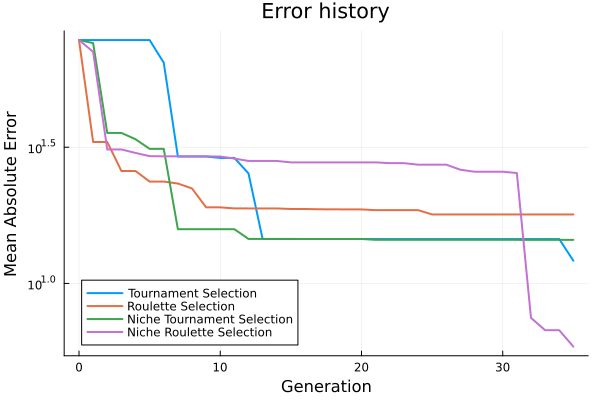

In [63]:
p = plot(0:generations, [tournament_hist, roulette_hist, tournament_niche_hist,
    roulette_niche_hist], yaxis=:log,
    title="Error history",
    xlabel="Generation",
    ylabel="Mean Absolute Error",
    label=["Tournament Selection" "Roulette Selection" "Niche Tournament Selection" "Niche Roulette Selection"],
    linewidth=2,
    legend=:bottomleft)

display(p)

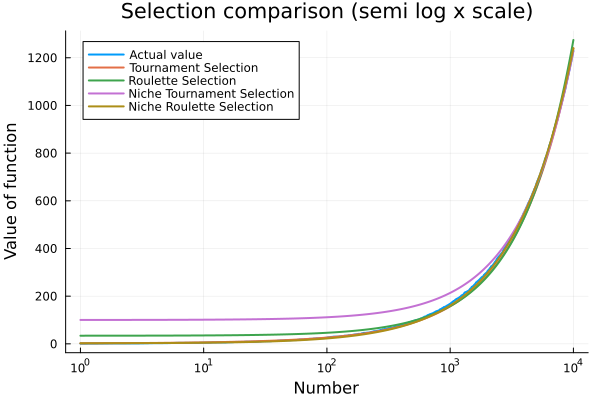

In [81]:
tournament_values = Float64[]
roulette_values = Float64[]
tournament_niche_values = Float64[]
roulette_niche_values = Float64[]
for j in 1:size(X, 1)
    assignValues!(best_tournament_tree.variables, X[j, :])
    push!(tournament_values, computeTree(best_tournament_tree))

    assignValues!(best_roulette_tree.variables, X[j, :])
    push!(roulette_values, computeTree(best_roulette_tree))

    assignValues!(best_tournament_niche_tree.variables, X[j, :])
    push!(tournament_niche_values, computeTree(best_tournament_niche_tree))

    assignValues!(best_roulette_niche_tree.variables, X[j, :])
    push!(roulette_niche_values, computeTree(best_roulette_niche_tree))
end

p = plot(1:size(X, 1), [y, tournament_values, roulette_values, tournament_niche_values, roulette_niche_values], xaxis=:log,
    title="Selection comparison (semi log x scale)",
    xlabel="Number",
    ylabel="Value of function",
    label=["Actual value" "Tournament Selection" "Roulette Selection" "Niche Tournament Selection" "Niche Roulette Selection"],
    linewidth=2,
    legend=:topleft)

display(p)

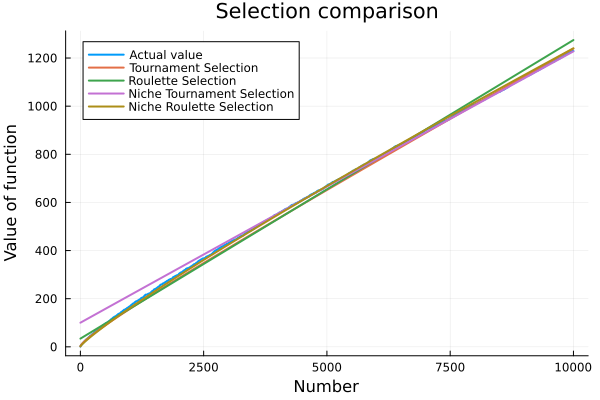

In [83]:
p = plot(1:size(X, 1), [y, tournament_values, roulette_values, tournament_niche_values, roulette_niche_values],
    title="Selection comparison",
    xlabel="Number",
    ylabel="Value of function",
    label=["Actual value" "Tournament Selection" "Roulette Selection" "Niche Tournament Selection" "Niche Roulette Selection"],
    linewidth=2,
    legend=:topleft)

display(p)

## 12. Results

### 12.1 $\pi$-function
To ensure statistical reliability, all four configurations — Tournament, Roulette, Niche Tournament, and Niche Roulette — were each executed 10 times from independently randomized but identical starting populations. The convergence curves below show the average MAE per generation across all 10 runs on a logarithmic scale, smoothing out the effect of any single lucky or unlucky initialization.

Several observations can be drawn from the plot. All four strategies converge at a comparable rate during the first 10 generations, suggesting that early-generation improvement is driven primarily by the genetic operators rather than the selection mechanism. After generation 10, the strategies begin to diverge noticeably.

The two standard (non-niche) strategies — Tournament and Roulette — plateau around $10^{1.5}$, indicating premature convergence to a local optimum. In contrast, both niche variants continue improving throughout the run, confirming that fitness sharing successfully maintains population diversity and prevents stagnation.

Most notably, **Niche Tournament Selection** achieves the lowest final MAE by a significant margin, dropping to  $16$ by generation 35. **Niche Roulette** follows closely, outperforming Tournament but falling short of Niche Tournament and Roulette.

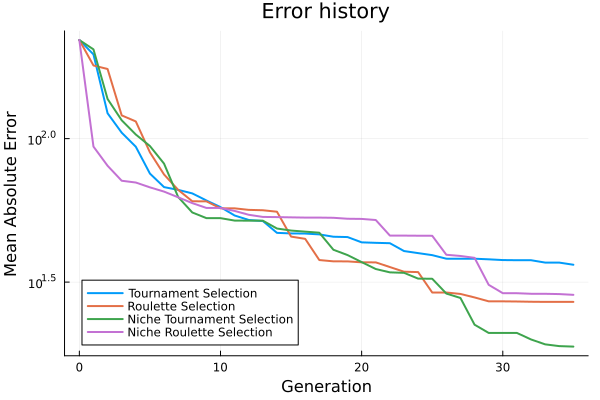

In [88]:
using DelimitedFiles
tournament_hist = readdlm("pi.csvfitness_hist_tournament.txt", Float64)[:, 1]
roulette_hist = readdlm("pi.csvfitness_hist_roulette.txt", Float64)[:, 1]
roulette_niche_hist = readdlm("pi.csvfitness_hist_roulette_niche.txt", Float64)[:, 1]
tournament_niche_hist = readdlm("pi.csvfitness_hist_tournament_niche.txt", Float64)[:, 1]

p = plot(0:generations, [tournament_hist, roulette_hist, tournament_niche_hist,
    roulette_niche_hist], yaxis=:log,
    title="Error history",
    xlabel="Generation",
    ylabel="Mean Absolute Error",
    label=["Tournament Selection" "Roulette Selection" "Niche Tournament Selection" "Niche Roulette Selection"],
    linewidth=2,
    legend=:bottomleft)

display(p)

The best expression found across all 10 iterations and all four configurations was:

$$\frac{x - \log\left( \frac{x}{\sin\left( \sqrt{\log\left( x \right)} \right)} \right)}{\log\left( \frac{x}{\sqrt{\log\left( \frac{\left\lceil x\right\rceil }{\log\left( 10.0 \right)} \right)}} \right)}$$

with a Mean Absolute Error of **1.43**. The expression is non-trivial — it combines logarithms, a square root, a ceiling function, and a sine, reflecting the GP's ability to construct complex compositions of primitives that would be impossible to find by hand or through simple parametric regression.

Regarding execution time, the non-niche variants were significantly faster — Tournament and Roulette averaged **33.0s** and **31.8s** respectively — while the niche variants incurred a substantial overhead, averaging **55.5s** (Niche Tournament) and **50.6s** (Niche Roulette). This is expected: fitness sharing requires computing pairwise phenotypic distances across the entire population at every generation, which scales as $O(N^2)$. The trade-off is clear — niching roughly doubles the runtime but delivers a meaningfully better final solution, making it worthwhile for this problem.

### 12.2 Euler function
To ensure statistical reliability, all four configurations were each executed 10 times from independently randomized but identical starting populations. The convergence curves below show the average MAE per generation across all 10 runs, smoothing out the effect of any single lucky or unlucky initialization.

Several observations can be drawn from the plot. All four strategies converge rapidly during the first 10 generations, with Niche Roulette and Niche Tournament separating from the pack almost immediately. Unlike the $\pi$ experiment, the standard variants do not plateau as early — both Tournament and Tournament Niche continue improving past generation 15 before stabilizing. Roulette Selection, however, converges noticeably slower than the remaining three strategies throughout the entire run.

The final average MAE rankings are as follows: **Niche Tournament (1523.62)**, **Tournament (1523.86)**, **Niche Roulette (1548.49)**, and **Roulette (1552.02)**. The gap between the top two and bottom two is consistent, but notably the margin between Niche Tournament and standard Tournament is negligible — suggesting that for this function, the diversity maintained by fitness sharing provides only a marginal advantage over plain tournament selection.


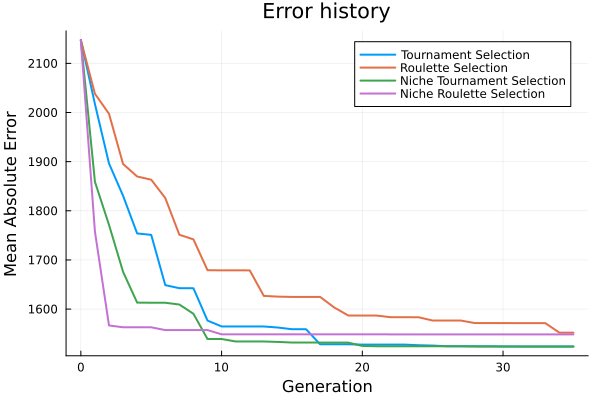

In [99]:
tournament_hist = readdlm("eul.csvfitness_hist_tournament.txt", Float64)[:, 1]
roulette_hist = readdlm("eul.csvfitness_hist_roulette.txt", Float64)[:, 1]
roulette_niche_hist = readdlm("eul.csvfitness_hist_roulette_niche.txt", Float64)[:, 1]
tournament_niche_hist = readdlm("eul.csvfitness_hist_tournament_niche.txt", Float64)[:, 1]

p = plot(0:generations, [tournament_hist, roulette_hist, tournament_niche_hist,
    roulette_niche_hist],
    title="Error history",
    xlabel="Generation",
    ylabel="Mean Absolute Error",
    label=["Tournament Selection" "Roulette Selection" "Niche Tournament Selection" "Niche Roulette Selection"],
    linewidth=2,
    legend=:topright)

display(p)

The best expression found across all 10 iterations and all four configurations was:

$$\left\lfloor \sin\left( \log\left( \left|6.0\right| \cdot x \cdot 9.0 \right) \right) - \frac{x}{2.0} + \left\lfloor x\right\rfloor  - \left|\left|\sin\left( 8.0 + \frac{2.0}{x} \right)\right|\right|\right\rfloor$$

with a Mean Absolute Error of **1522.95**, substantially higher than the $\pi$ approximation result of **1.43**. This reflects the increased difficulty of the target function — the GP struggled to find a compact closed-form expression that captures the global behavior of the Euler function within the allotted generations and population size.

Regarding execution time, the increased complexity of the search space is evident in the runtimes. Non-niche variants averaged **68.7s** (Tournament) and **56.7s** (Roulette), while niche variants required **109.2s** and **111.2s** respectively — roughly double in both cases.

## 13. Conclusion

The results suggest that niching via fitness sharing can improve final solution quality by maintaining population diversity and preventing premature convergence, as clearly demonstrated by Niche Tournament Selection achieving the lowest average MAE (but not significantly better). However, this improvement is neither consistent across all runs nor guaranteed — in several individual iterations, the standard variants performed comparably or even better than their niche counterparts.

More critically, the computational cost of fitness sharing is substantial. The $O(N^2)$ pairwise distance computation roughly doubles runtime each generation. In general, the marginal quality gains achieved through niching do not justify the twofold increase in computational cost.

P.S. Maybe I have implemented fitness sharing incorrectly, but Gemini and Claude told that it was correct